In [1]:
# Set up data paths
TRAIN_JSON = "/home/ubuntu/brianwu/data/openimages/faces_coco/annotations/instances_train.json"
VAL_JSON   = "/home/ubuntu/brianwu/data/openimages/faces_coco/annotations/instances_val.json"
IMAGE_BASE_PATH = "/home/ubuntu/brianwu/data/openimages/faces"
DEVICE = "cuda"
SEED = 42

In [2]:
# Define Training Hyperparameters
NUM_EPOCHS   = 1
BATCH_SIZE   = 4
NUM_WORKERS  = 0
PRINT_EVERY  = 50

In [3]:
!pip install torch torchvision pycocotools albumentations opencv-python tqdm matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import os, json, random, math, time
from pathlib import Path
from typing import List, Dict, Any
from collections import defaultdict
import torch
import torch.multiprocessing
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from PIL import Image
from tqdm import tqdm
import pprint
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    print("CUDA IS AVAILABLE")
    torch.cuda.manual_seed_all(SEED)

torch.multiprocessing.set_sharing_strategy('file_system')

CUDA IS AVAILABLE


In [5]:
class COCOSingleClassFaces(Dataset):
    """A minimal COCO reader for a single 'face' category (id=1)."""
    def __init__(self, ann_file: str, image_base: str = None, transform=None):
        with open(ann_file, "r") as f:
            data = json.load(f)
        self.images = data["images"]
        self.annos = data["annotations"]
        self.cat_id = 1
        self.transform = transform

        # index annotations by image_id
        ann_by_img = {}
        for ann in self.annos:
            if ann.get("category_id") != self.cat_id:
                continue
            img_id = ann["image_id"]
            ann_by_img.setdefault(img_id, []).append(ann)
        self.ann_by_img = ann_by_img

        self.image_base = image_base

    def __len__(self):
        return len(self.images)

    def _resolve_path(self, name: str):
        p = Path(name)
        if p.is_absolute():
            return p
        if self.image_base:
            return Path(self.image_base) / name
        return p

    def __getitem__(self, idx):
        img_rec = self.images[idx]
        img_path = self._resolve_path(img_rec["file_name"])
        img = Image.open(img_path).convert("RGB")

        # boxes/labels
        anns = self.ann_by_img.get(img_rec["id"], [])
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for a in anns:
            x, y, w, h = a["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(1)  # single class: face
            areas.append(a.get("area", w*h))
            iscrowd.append(a.get("iscrowd", 0))

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4), dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            "image_id": torch.tensor([img_rec["id"]], dtype=torch.int64),
            "area": torch.tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,), dtype=torch.float32),
            "iscrowd": torch.tensor(iscrowd, dtype=torch.int64) if iscrowd else torch.zeros((0,), dtype=torch.int64),
            "path": str(img_path),
        }

        if self.transform:
            img = self.transform(img)

        return img, target


In [6]:
train_tf = transforms.Compose([
    transforms.ToTensor(),  # converts HWC in [0,255] to CHW float in [0,1]
])

val_tf = transforms.Compose([
    transforms.ToTensor(),
])

def collate_fn(batch):
    imgs, targets = list(zip(*batch))
    return list(imgs), list(targets)

In [7]:
train_ds = COCOSingleClassFaces(TRAIN_JSON, IMAGE_BASE_PATH, transform=train_tf)
val_ds   = COCOSingleClassFaces(VAL_JSON, IMAGE_BASE_PATH, transform=val_tf)

# Create Subset
# train_ds = torch.utils.data.Subset(train_ds, range(2000))

print(f"Train images: {len(train_ds)}  |  Val images: {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)

Train images: 191249  |  Val images: 21249


In [8]:
def visualize_training_samples(dataset, num_samples=4):
    """Visualize training images with their ground truth bounding boxes."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i in range(min(num_samples, len(dataset))):
        img, target = dataset[i]
        
        # Convert tensor to numpy for visualization
        if isinstance(img, torch.Tensor):
            img_np = img.permute(1, 2, 0).numpy()
        else:
            img_np = np.array(img)
        
        ax = axes[i]
        ax.imshow(img_np)
        ax.set_title(f"Image {i+1}: {target['boxes'].shape[0]} faces")
        ax.axis('off')
        
        # Draw bounding boxes
        for box in target['boxes']:
            x1, y1, x2, y2 = box.numpy() if isinstance(box, torch.Tensor) else box
            width = x2 - x1
            height = y2 - y1
            
            rect = patches.Rectangle((x1, y1), width, height, 
                                   linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
    
    plt.tight_layout()
    plt.show()

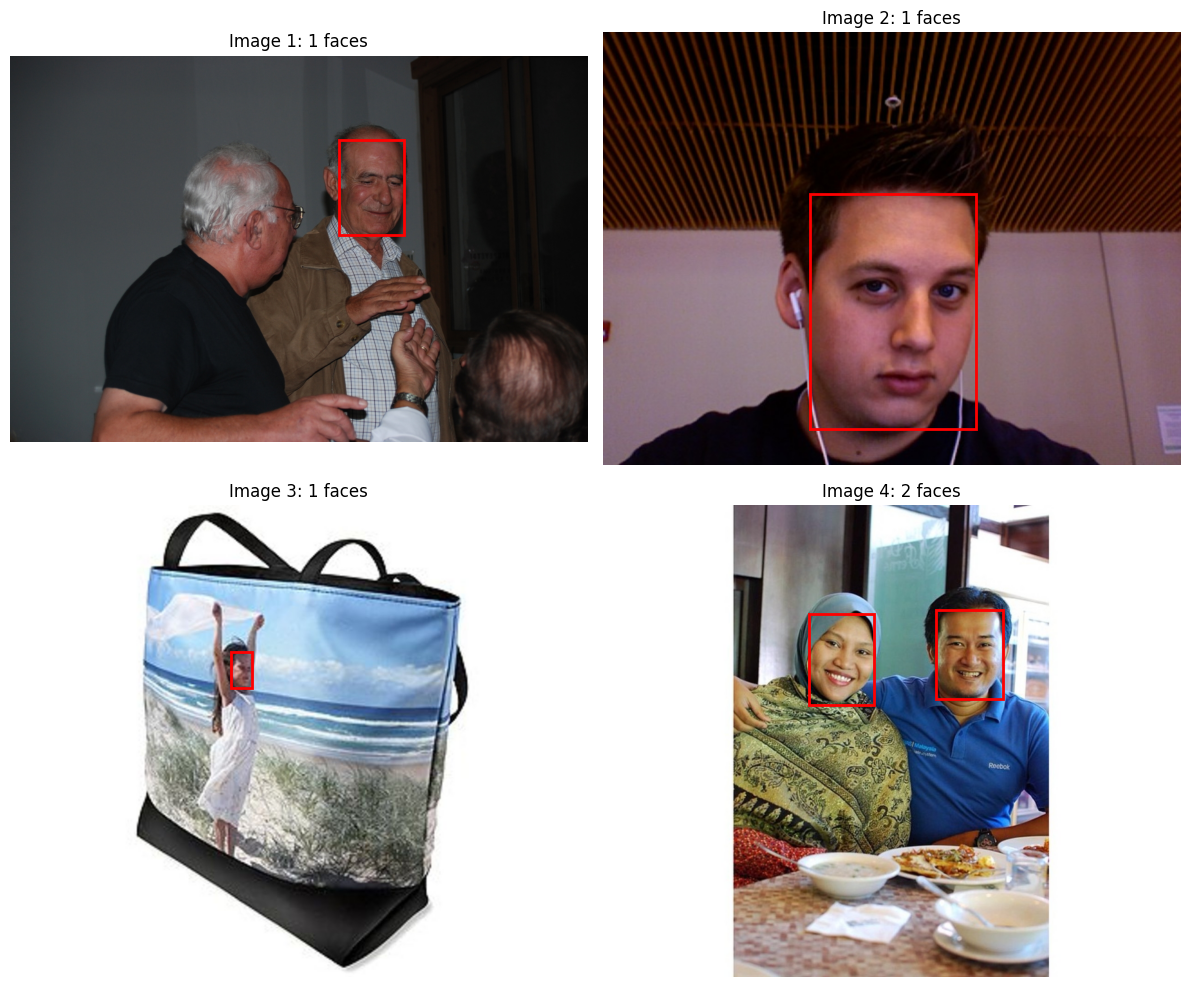

In [9]:
visualize_training_samples(train_ds, num_samples=4)

In [10]:
# num_classes = background + face
num_classes = 2
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None, num_classes=num_classes)
model.to(DEVICE)

# Improved Learning Rate Strategy
def get_lr_scheduler_with_warmup(optimizer, warmup_epochs=2, total_epochs=15):
    """Learning rate scheduler with warmup and cosine annealing."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            # Warmup phase: gradually increase LR
            return (epoch + 1) / warmup_epochs
        else:
            # Cosine annealing after warmup
            import math
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return 0.5 * (1 + math.cos(math.pi * progress))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Alternative plateau-based scheduler
def get_plateau_scheduler(optimizer):
    """Reduce LR when loss plateaus."""
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True, min_lr=1e-6
    )

# Optimizer with improved LR
LR_IMPROVED = 0.001  # Start with slightly higher LR
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR_IMPROVED, momentum=0.9, weight_decay=1e-4)

# Use warmup + cosine annealing scheduler (better than step decay)
lr_sch = get_lr_scheduler_with_warmup(optimizer, warmup_epochs=2, total_epochs=15)

# Uncomment below to use plateau-based scheduling instead:
# lr_sch = get_plateau_scheduler(optimizer)

print(f"Updated LR to {LR_IMPROVED} with warmup + cosine annealing scheduler")

Updated LR to 0.001 with warmup + cosine annealing scheduler


In [11]:
def train_one_epoch(model, loader, optimizer, device="cuda", print_every=50):
    model.train()
    running = 0.0
    for i, (imgs, targets) in enumerate(loader):
        imgs = [im.to(device) for im in imgs]
        tgts = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k,v in t.items()} for t in targets]

        loss_dict = model(imgs, tgts)
        loss = sum(loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += float(loss.item())
        if (i+1) % print_every == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"[{i+1}/{len(loader)}] loss={running/print_every:.4f}, lr={current_lr:.6f}")
            
            # Print individual loss components for debugging
            loss_str = ", ".join([f"{k}={v:.4f}" for k, v in loss_dict.items()])
            print(f"  Loss components: {loss_str}")
            
            running = 0.0

def evaluate_sample(model, loader, device="cuda", max_images=10, score_thresh=0.5):
    model.eval()
    out = []
    with torch.no_grad():
        for i, (imgs, targets) in enumerate(loader):
            if i >= max_images:
                break
            img = imgs[0].to(device)
            pred = model([img])[0]
            # filter by score
            keep = pred["scores"] >= score_thresh
            boxes = pred["boxes"][keep].cpu().numpy().tolist()
            scores = pred["scores"][keep].cpu().numpy().tolist()

            # Format like RetinaFace (landmarks not available => None)
            faces = {}
            for j, (b, s) in enumerate(zip(boxes, scores), start=1):
                x1, y1, x2, y2 = b
                faces[f"face_{j}"] = {
                    "score": float(s),
                    "facial_area": [float(x1), float(y1), float(x2), float(y2)],
                    "landmarks": None  # requires landmark annotations to train
                }
            out.append({"image_path": targets[0]["path"], "predictions": faces})
    return out

In [ ]:
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    train_one_epoch(model, train_loader, optimizer, device=DEVICE, print_every=PRINT_EVERY)
    lr_sch.step()
print("Training finished.")

Epoch 1/1
[50/47813] loss=0.7764, lr=0.000500
  Loss components: loss_classifier=0.2055, loss_box_reg=0.0886, loss_objectness=0.1055, loss_rpn_box_reg=0.0149
[100/47813] loss=0.3782, lr=0.000500
  Loss components: loss_classifier=0.1281, loss_box_reg=0.1053, loss_objectness=0.0884, loss_rpn_box_reg=0.0136
[150/47813] loss=0.3751, lr=0.000500
  Loss components: loss_classifier=0.1416, loss_box_reg=0.1792, loss_objectness=0.0449, loss_rpn_box_reg=0.0108


In [ ]:
SAVE_PATH = "face_detector_frcnn_v1_initial.pt"
torch.save({"model": model.state_dict()}, SAVE_PATH)
print("Saved:", SAVE_PATH)

In [ ]:
def visualize_predictions(model, loader, device="cuda", num_images=3, score_thresh=0.6):
    """Visualize model predictions with bounding boxes on images."""
    model.eval()
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    if num_images == 1:
        axes = [axes]
    
    with torch.no_grad():
        for i, (imgs, targets) in enumerate(loader):
            if i >= num_images:
                break
                
            img_tensor = imgs[0].to(device)
            pred = model([img_tensor])[0]
            
            # Filter predictions by score threshold
            keep = pred["scores"] >= score_thresh
            boxes = pred["boxes"][keep].cpu().numpy()
            scores = pred["scores"][keep].cpu().numpy()
            
            # Convert image tensor to numpy for display
            img_np = imgs[0].permute(1, 2, 0).numpy()
            
            ax = axes[i]
            ax.imshow(img_np)
            ax.set_title(f"Image {i+1}: {len(boxes)} faces detected")
            ax.axis('off')
            
            # Draw predicted bounding boxes
            for box, score in zip(boxes, scores):
                x1, y1, x2, y2 = box
                width = x2 - x1
                height = y2 - y1
                
                rect = patches.Rectangle((x1, y1), width, height, 
                                       linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                
                # Add confidence score as text
                ax.text(x1, y1-5, f'{score:.2f}', 
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lime', alpha=0.7),
                       fontsize=10, color='black')
    
    plt.tight_layout()
    plt.show()

In [ ]:
samples = evaluate_sample(model, val_loader, device=DEVICE, max_images=3, score_thresh=0.6)
pprint.pprint(samples[:1])

In [ ]:
visualize_predictions(model, val_loader, device=DEVICE, num_images=5, score_thresh=0.6)

In [ ]:
SAVE_PATH = "face_detector_frcnn_v1.pt"
torch.save({"model": model.state_dict()}, SAVE_PATH)
print("Saved:", SAVE_PATH)

In [ ]:
def calculate_iou(box1, box2):
    """Calculate IoU between two bounding boxes."""
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Calculate intersection area
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    if inter_x_max <= inter_x_min or inter_y_max <= inter_y_min:
        return 0.0
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    
    # Calculate union area
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

def calculate_ap(precisions, recalls):
    """Calculate Average Precision using 11-point interpolation."""
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11.0
    return ap

def evaluate_model_full(model, loader, device="cuda", iou_thresh=0.5, score_thresh=0.3):
    """Comprehensive evaluation with mAP and mIOU metrics."""
    model.eval()
    
    all_predictions = []
    all_gt_boxes = []
    all_ious = []
    
    print("Running full evaluation...")
    
    with torch.no_grad():
        for i, (imgs, targets) in enumerate(tqdm(loader)):
            if i % 100 == 0:
                print(f"Processed {i}/{len(loader)} images")
            
            img = imgs[0].to(device)
            pred = model([img])[0]
            
            # Get predictions above score threshold
            keep = pred["scores"] >= score_thresh
            pred_boxes = pred["boxes"][keep].cpu().numpy()
            pred_scores = pred["scores"][keep].cpu().numpy()
            
            # Get ground truth boxes
            gt_boxes = targets[0]["boxes"].cpu().numpy()
            
            # Store for mAP calculation
            for box, score in zip(pred_boxes, pred_scores):
                all_predictions.append({
                    'image_id': i,
                    'bbox': box,
                    'score': score,
                    'category_id': 1
                })
            
            # Store GT boxes
            for box in gt_boxes:
                all_gt_boxes.append({
                    'image_id': i,
                    'bbox': box,
                    'category_id': 1
                })
            
            # Calculate IoUs for this image
            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                for pred_box in pred_boxes:
                    best_iou = 0
                    for gt_box in gt_boxes:
                        iou = calculate_iou(pred_box, gt_box)
                        best_iou = max(best_iou, iou)
                    all_ious.append(best_iou)
    
    # Calculate mIOU
    mean_iou = np.mean(all_ious) if all_ious else 0.0
    
    # Calculate mAP
    if not all_predictions:
        return {
            'mAP@0.5': 0.0,
            'mIOU': mean_iou,
            'precision': 0.0,
            'recall': 0.0,
            'num_predictions': 0,
            'num_gt_boxes': len(all_gt_boxes)
        }
    
    # Group predictions and GT by image
    pred_by_img = defaultdict(list)
    gt_by_img = defaultdict(list)
    
    for pred in all_predictions:
        pred_by_img[pred['image_id']].append(pred)
    for gt in all_gt_boxes:
        gt_by_img[gt['image_id']].append(gt)
    
    # Sort predictions by confidence
    all_predictions.sort(key=lambda x: x['score'], reverse=True)
    
    # Calculate precision and recall at each threshold
    tp = 0
    fp = 0
    precisions = []
    recalls = []
    
    matched_gt = set()  # Track matched ground truth boxes
    
    for pred in all_predictions:
        img_id = pred['image_id']
        pred_box = pred['bbox']
        
        # Find best matching GT box
        best_iou = 0
        best_gt_idx = -1
        
        for gt_idx, gt in enumerate(gt_by_img[img_id]):
            gt_box = gt['bbox']
            iou = calculate_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        # Check if it's a true positive
        gt_key = (img_id, best_gt_idx)
        if best_iou >= iou_thresh and gt_key not in matched_gt:
            tp += 1
            matched_gt.add(gt_key)
        else:
            fp += 1
        
        # Calculate precision and recall
        precision = tp / (tp + fp)
        recall = tp / len(all_gt_boxes) if all_gt_boxes else 0
        
        precisions.append(precision)
        recalls.append(recall)
    
    # Convert to numpy arrays
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    
    # Calculate AP
    ap = calculate_ap(precisions, recalls)
    
    # Final metrics
    final_precision = precisions[-1] if precisions.size > 0 else 0
    final_recall = recalls[-1] if recalls.size > 0 else 0
    
    return {
        'mAP@0.5': ap,
        'mIOU': mean_iou,
        'precision': final_precision,
        'recall': final_recall,
        'num_predictions': len(all_predictions),
        'num_gt_boxes': len(all_gt_boxes),
        'tp': tp,
        'fp': fp
    }

In [ ]:
print("Starting comprehensive evaluation on validation set...")
metrics = evaluate_model_full(model, val_loader, device=DEVICE, iou_thresh=0.5, score_thresh=0.3)

print("\n=== EVALUATION RESULTS ===")
print(f"mAP@0.5: {metrics['mAP@0.5']:.4f}")
print(f"mIOU: {metrics['mIOU']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"True Positives: {metrics['tp']}")
print(f"False Positives: {metrics['fp']}")
print(f"Total Predictions: {metrics['num_predictions']}")
print(f"Total Ground Truth Boxes: {metrics['num_gt_boxes']}")